In [8]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc, 
                             classification_report)

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")
print(f"Current working directory: {os.getcwd()}")

# Check for trust_model module
try:
    from trust_model import TrustScoreCalculator, add_trust_scores_to_dataframe
    print("✅ Trust Score Module loaded successfully!")
except ImportError as e:
    print(f"⚠️ Trust Score Module not found. Error: {e}")

✅ All libraries imported successfully!
Current working directory: d:\Projects\IoTGeM
✅ Trust Score Module loaded successfully!


In [9]:
# SELECT A DATASET CONFIGURATION (RESEARCH-GRADE INPUT GENERATION)
# These settings generate reproducible, scenario-controlled synthetic IoT traffic.
# Use this when real packet-level CSV is unavailable or for controlled ablation studies.

config_name = "BALANCED_RESEARCH"  # Options: "NORMAL_HEAVY", "BALANCED_RESEARCH", "ATTACK_STRESS", "LARGE_RESEARCH"

print(f"📊 Configuration Selected: {config_name}")
print("=" * 80)

configs = {
    "NORMAL_HEAVY": {
        "description": "Normal-heavy IoT traffic (good for low-prevalence attack evaluation)",
        "n_samples": 3000,
        "attack_ratio": 0.20,
        "n_devices": 12,
        "duration_seconds": 7200,
        "random_seed": 42,
        "protocols": [6, 17, 1],
        "benign_protocol_probs": [0.60, 0.30, 0.10],
        "attack_protocol_probs": [0.40, 0.30, 0.30],
        "packet_size_normal": {"mean": 420, "std": 140, "min": 60, "max": 1600},
        "packet_size_attack": {"mean": 920, "std": 280, "min": 40, "max": 2000},
        "base_inter_arrival_normal": 0.70,
        "base_inter_arrival_attack": 0.18,
        "device_compromised_fraction": 0.25,
        "attack_mix": {"flood": 0.45, "scan": 0.25, "fragmentation": 0.20, "protocol_abuse": 0.10}
    },
    "BALANCED_RESEARCH": {
        "description": "Balanced class scenario with realistic behavioral drift (recommended)",
        "n_samples": 4000,
        "attack_ratio": 0.45,
        "n_devices": 14,
        "duration_seconds": 10800,
        "random_seed": 42,
        "protocols": [6, 17, 1, 58],
        "benign_protocol_probs": [0.58, 0.30, 0.08, 0.04],
        "attack_protocol_probs": [0.30, 0.25, 0.20, 0.25],
        "packet_size_normal": {"mean": 460, "std": 150, "min": 60, "max": 1800},
        "packet_size_attack": {"mean": 980, "std": 320, "min": 40, "max": 2400},
        "base_inter_arrival_normal": 0.65,
        "base_inter_arrival_attack": 0.14,
        "device_compromised_fraction": 0.35,
        "attack_mix": {"flood": 0.40, "scan": 0.25, "fragmentation": 0.20, "protocol_abuse": 0.15}
    },
    "ATTACK_STRESS": {
        "description": "Attack-dominant stress test for IDS robustness",
        "n_samples": 3500,
        "attack_ratio": 0.70,
        "n_devices": 10,
        "duration_seconds": 5400,
        "random_seed": 42,
        "protocols": [6, 17, 1, 47],
        "benign_protocol_probs": [0.62, 0.26, 0.09, 0.03],
        "attack_protocol_probs": [0.22, 0.20, 0.18, 0.40],
        "packet_size_normal": {"mean": 430, "std": 130, "min": 60, "max": 1500},
        "packet_size_attack": {"mean": 1050, "std": 360, "min": 40, "max": 2600},
        "base_inter_arrival_normal": 0.72,
        "base_inter_arrival_attack": 0.10,
        "device_compromised_fraction": 0.50,
        "attack_mix": {"flood": 0.50, "scan": 0.20, "fragmentation": 0.15, "protocol_abuse": 0.15}
    },
    "LARGE_RESEARCH": {
        "description": "Larger-scale scenario for stable metrics and confidence analysis",
        "n_samples": 9000,
        "attack_ratio": 0.35,
        "n_devices": 24,
        "duration_seconds": 21600,
        "random_seed": 42,
        "protocols": [6, 17, 1, 58],
        "benign_protocol_probs": [0.57, 0.31, 0.08, 0.04],
        "attack_protocol_probs": [0.33, 0.26, 0.18, 0.23],
        "packet_size_normal": {"mean": 470, "std": 160, "min": 60, "max": 1800},
        "packet_size_attack": {"mean": 950, "std": 310, "min": 40, "max": 2400},
        "base_inter_arrival_normal": 0.64,
        "base_inter_arrival_attack": 0.15,
        "device_compromised_fraction": 0.30,
        "attack_mix": {"flood": 0.42, "scan": 0.23, "fragmentation": 0.20, "protocol_abuse": 0.15}
    }
}

current_config = configs[config_name]
print("\n📋 Configuration Details:")
print(f"   {current_config['description']}")
print(f"   Samples: {current_config['n_samples']}")
print(f"   Base Attack Ratio: {current_config['attack_ratio']:.2f}")
print(f"   Devices: {current_config['n_devices']}")
print(f"   Duration: {current_config['duration_seconds']} sec")
print(f"   Protocol Set: {current_config['protocols']}")
print(f"   Compromised Device Fraction: {current_config['device_compromised_fraction']:.2f}")
print(f"   Attack Mix: {current_config['attack_mix']}")
print("\n💡 Recommendation for publication table: BALANCED_RESEARCH or LARGE_RESEARCH")

📊 Configuration Selected: BALANCED_RESEARCH

📋 Configuration Details:
   Balanced class scenario with realistic behavioral drift (recommended)
   Samples: 4000
   Base Attack Ratio: 0.45
   Devices: 14
   Duration: 10800 sec
   Protocol Set: [6, 17, 1, 58]
   Compromised Device Fraction: 0.35
   Attack Mix: {'flood': 0.4, 'scan': 0.25, 'fragmentation': 0.2, 'protocol_abuse': 0.15}

💡 Recommendation for publication table: BALANCED_RESEARCH or LARGE_RESEARCH


In [10]:
rng = np.random.default_rng(current_config['random_seed'])
np.random.seed(current_config['random_seed'])

n_samples = current_config['n_samples']
attack_ratio = current_config['attack_ratio']
duration_seconds = current_config['duration_seconds']
protocols = current_config['protocols']
benign_protocol_probs = np.array(current_config['benign_protocol_probs'], dtype=float)
attack_protocol_probs = np.array(current_config['attack_protocol_probs'], dtype=float)
attack_mix = current_config['attack_mix']

# Normalize probabilities for safety
benign_protocol_probs = benign_protocol_probs / benign_protocol_probs.sum()
attack_protocol_probs = attack_protocol_probs / attack_protocol_probs.sum()

# Device pool
n_devices = current_config['n_devices']
device_ips = [f"192.168.1.{100 + i}" for i in range(n_devices)]
gateway_ips = ['192.168.1.1', '8.8.8.8', '1.1.1.1', '9.9.9.9']

# Mark a subset of devices as more likely to be compromised
n_compromised = max(1, int(n_devices * current_config['device_compromised_fraction']))
compromised_devices = set(rng.choice(device_ips, size=n_compromised, replace=False).tolist())

# Per-device baseline behavior profiles
device_profiles = {}
for ip in device_ips:
    preferred_protocol = int(rng.choice(protocols, p=benign_protocol_probs))
    device_profiles[ip] = {
        'preferred_protocol': preferred_protocol,
        'pkt_mean': float(rng.normal(current_config['packet_size_normal']['mean'], 35)),
        'pkt_std': float(np.clip(rng.normal(current_config['packet_size_normal']['std'], 20), 40, 260)),
        'ack_prob': float(np.clip(rng.normal(0.83, 0.06), 0.65, 0.95)),
        'fin_prob': float(np.clip(rng.normal(0.15, 0.05), 0.02, 0.35))
    }

# Device activity distribution (some devices talk more)
device_activity = rng.dirichlet(alpha=np.ones(n_devices) * 1.8)

rows = []
current_time = 0.0
attack_types = list(attack_mix.keys())
attack_probs = np.array(list(attack_mix.values()), dtype=float)
attack_probs = attack_probs / attack_probs.sum()
attack_type_log = []

for _ in range(n_samples):
    ip_src = str(rng.choice(device_ips, p=device_activity))
    profile = device_profiles[ip_src]

    # Device-specific attack probability (compromised devices are more attack-prone)
    if ip_src in compromised_devices:
        local_attack_ratio = min(0.95, attack_ratio + 0.25)
    else:
        local_attack_ratio = max(0.01, attack_ratio - 0.08)

    label = int(rng.random() < local_attack_ratio)
    attack_type = None

    if label == 0:
        # Benign inter-arrival (more regular)
        dt = float(rng.exponential(current_config['base_inter_arrival_normal']))
        ip_proto = int(profile['preferred_protocol'] if rng.random() < 0.75 else rng.choice(protocols, p=benign_protocol_probs))
        pck_size = int(np.clip(rng.normal(profile['pkt_mean'], profile['pkt_std']),
                               current_config['packet_size_normal']['min'],
                               current_config['packet_size_normal']['max']))
        tcp_ack = int(rng.random() < profile['ack_prob'])
        tcp_fin = int(rng.random() < profile['fin_prob'])
        ip_flags = int(rng.choice([0, 1, 2, 3], p=[0.70, 0.20, 0.08, 0.02]))
        ip_ihl = int(rng.choice([5, 6], p=[0.93, 0.07]))
        ip_frag = int(rng.random() < 0.03)
        ip_dst = str(rng.choice(gateway_ips, p=[0.60, 0.20, 0.15, 0.05]))

    else:
        attack_type = str(rng.choice(attack_types, p=attack_probs))

        if attack_type == 'flood':
            dt = float(rng.exponential(current_config['base_inter_arrival_attack'] * 0.45))
            ip_proto = int(rng.choice(protocols, p=attack_protocol_probs))
            pck_size = int(np.clip(rng.normal(current_config['packet_size_attack']['mean'] + 250,
                                             current_config['packet_size_attack']['std']),
                                   current_config['packet_size_attack']['min'],
                                   current_config['packet_size_attack']['max']))
            tcp_ack = int(rng.random() < 0.20)
            tcp_fin = int(rng.random() < 0.05)
            ip_flags = int(rng.choice([0, 1, 2, 3], p=[0.15, 0.20, 0.35, 0.30]))
            ip_ihl = int(rng.choice([5, 6], p=[0.80, 0.20]))
            ip_frag = int(rng.random() < 0.18)

        elif attack_type == 'scan':
            dt = float(rng.exponential(current_config['base_inter_arrival_attack'] * 0.75))
            ip_proto = int(rng.choice(protocols, p=attack_protocol_probs))
            pck_size = int(np.clip(rng.normal(180, 70), 40, 700))
            tcp_ack = int(rng.random() < 0.10)
            tcp_fin = int(rng.random() < 0.45)
            ip_flags = int(rng.choice([0, 1, 2, 3], p=[0.20, 0.20, 0.30, 0.30]))
            ip_ihl = int(rng.choice([5, 6], p=[0.85, 0.15]))
            ip_frag = int(rng.random() < 0.08)

        elif attack_type == 'fragmentation':
            dt = float(rng.exponential(current_config['base_inter_arrival_attack'] * 0.95))
            ip_proto = int(rng.choice(protocols, p=attack_protocol_probs))
            pck_size = int(np.clip(rng.normal(780, 260), 120, 2200))
            tcp_ack = int(rng.random() < 0.25)
            tcp_fin = int(rng.random() < 0.10)
            ip_flags = int(rng.choice([1, 2, 3], p=[0.15, 0.35, 0.50]))
            ip_ihl = 6
            ip_frag = int(rng.random() < 0.80)

        else:  # protocol_abuse
            dt = float(rng.exponential(current_config['base_inter_arrival_attack'] * 0.85))
            ip_proto = int(rng.choice(protocols, p=attack_protocol_probs))
            pck_size = int(np.clip(rng.normal(620, 290), 60, 2400))
            tcp_ack = int(rng.random() < 0.18)
            tcp_fin = int(rng.random() < 0.08)
            ip_flags = int(rng.choice([0, 1, 2, 3], p=[0.25, 0.20, 0.25, 0.30]))
            ip_ihl = int(rng.choice([5, 6], p=[0.55, 0.45]))
            ip_frag = int(rng.random() < 0.30)

        ip_dst = str(rng.choice(gateway_ips, p=[0.20, 0.35, 0.30, 0.15]))
        attack_type_log.append(attack_type)

    current_time += dt

    rows.append({
        'ts': round(min(current_time, duration_seconds), 6),
        'IP_src': ip_src,
        'IP_dst': ip_dst,
        'pck_size': pck_size,
        'IP_proto': ip_proto,
        'TCP_ACK': tcp_ack,
        'TCP_FIN': tcp_fin,
        'IP_flags': ip_flags,
        'IP_ihl': ip_ihl,
        'IP_frag': ip_frag,
        'label': label
    })

df_original = pd.DataFrame(rows)

# Ensure monotonic timeline in case capped values are repeated
df_original['ts'] = np.maximum.accumulate(df_original['ts'].values)

print("📊 Dataset Overview:")
print(f"Total samples: {len(df_original)}")
print(f"Features: {df_original.columns.tolist()}")
print(f"Compromised devices ({len(compromised_devices)}): {sorted(compromised_devices)}")

print("\n🧪 Research-quality checks:")
print(f"Label distribution: {df_original['label'].value_counts().to_dict()}")
print(f"Protocol distribution: {df_original['IP_proto'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Packet size mean±std: {df_original['pck_size'].mean():.2f} ± {df_original['pck_size'].std():.2f}")
print(f"Monotonic timestamps: {df_original['ts'].is_monotonic_increasing}")

if len(attack_type_log) > 0:
    print(f"Attack-type mix (observed): {pd.Series(attack_type_log).value_counts(normalize=True).round(3).to_dict()}")

print("\nFirst 5 rows:")
print(df_original.head())

📊 Dataset Overview:
Total samples: 4000
Features: ['ts', 'IP_src', 'IP_dst', 'pck_size', 'IP_proto', 'TCP_ACK', 'TCP_FIN', 'IP_flags', 'IP_ihl', 'IP_frag', 'label']
Compromised devices (4): ['192.168.1.100', '192.168.1.106', '192.168.1.108', '192.168.1.109']

🧪 Research-quality checks:
Label distribution: {0: 2095, 1: 1905}
Protocol distribution: {6: 0.463, 17: 0.311, 58: 0.124, 1: 0.102}
Packet size mean±std: 625.24 ± 395.17
Monotonic timestamps: True
Attack-type mix (observed): {'flood': 0.404, 'scan': 0.237, 'fragmentation': 0.199, 'protocol_abuse': 0.16}

First 5 rows:
         ts         IP_src       IP_dst  pck_size  IP_proto  TCP_ACK  TCP_FIN  \
0  0.694102  192.168.1.109  192.168.1.1       315         6        0        0   
1  1.696220  192.168.1.112  192.168.1.1       490         6        1        0   
2  1.868167  192.168.1.103      8.8.8.8       933         6        0        0   
3  1.898222  192.168.1.109  192.168.1.1       110        58        0        1   
4  2.275846  19

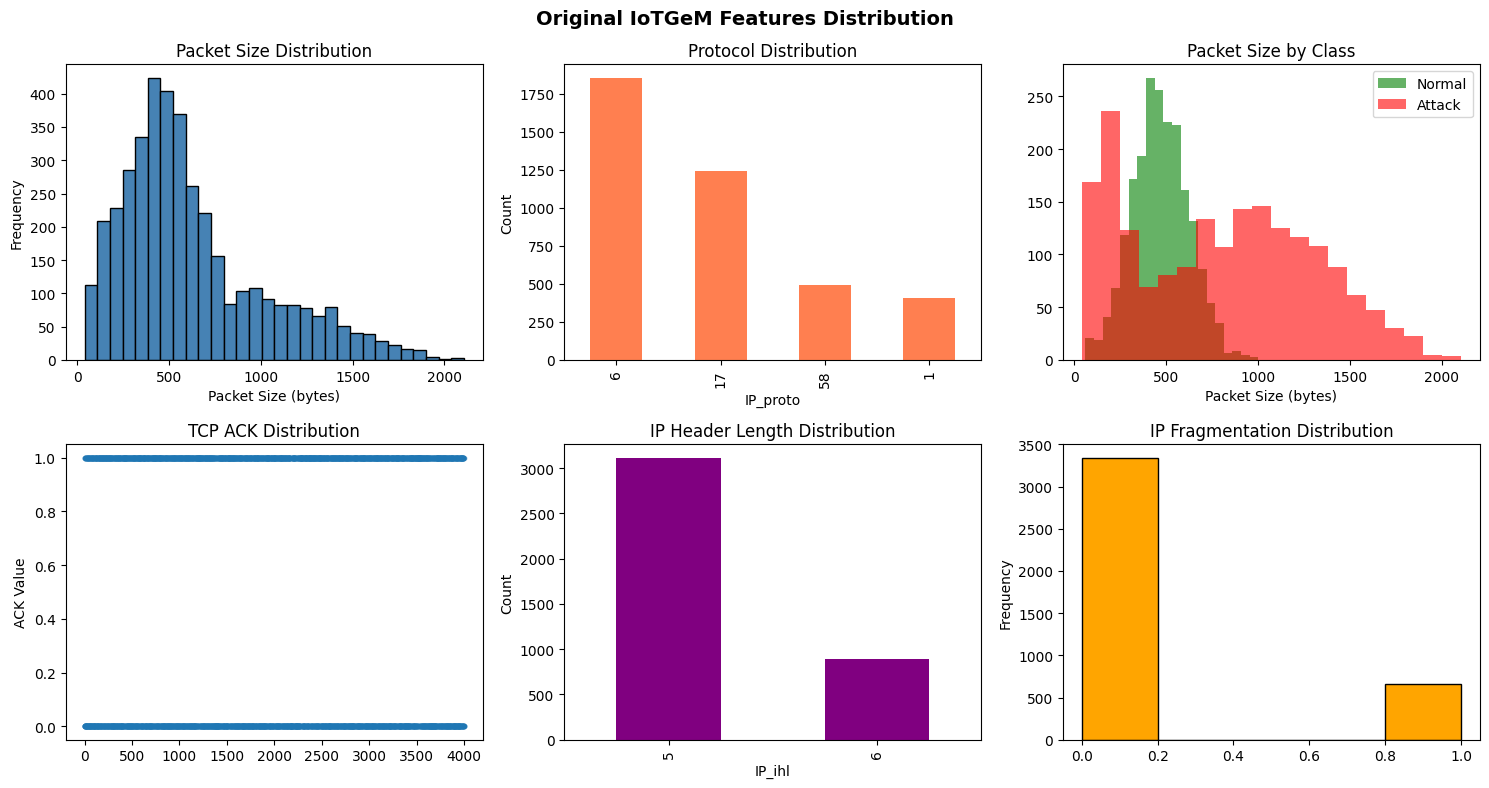

✅ Feature exploration complete


In [11]:
# Visualize original features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Original IoTGeM Features Distribution', fontsize=14, fontweight='bold')

axes[0, 0].hist(df_original['pck_size'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Packet Size Distribution')
axes[0, 0].set_xlabel('Packet Size (bytes)')
axes[0, 0].set_ylabel('Frequency')

df_original['IP_proto'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Protocol Distribution')
axes[0, 1].set_ylabel('Count')

axes[0, 2].hist(df_original[df_original['label']==0]['pck_size'], bins=20, 
                alpha=0.6, label='Normal', color='green')
axes[0, 2].hist(df_original[df_original['label']==1]['pck_size'], bins=20, 
                alpha=0.6, label='Attack', color='red')
axes[0, 2].set_title('Packet Size by Class')
axes[0, 2].set_xlabel('Packet Size (bytes)')
axes[0, 2].legend()

axes[1, 0].scatter(range(len(df_original)), df_original['TCP_ACK'], alpha=0.5, s=10)
axes[1, 0].set_title('TCP ACK Distribution')
axes[1, 0].set_ylabel('ACK Value')

df_original['IP_ihl'].value_counts().plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('IP Header Length Distribution')
axes[1, 1].set_ylabel('Count')

axes[1, 2].hist(df_original['IP_frag'], bins=5, color='orange', edgecolor='black')
axes[1, 2].set_title('IP Fragmentation Distribution')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("✅ Feature exploration complete")

In [12]:
# SELECT TRUST SCORE WEIGHT CONFIGURATION
# Change weight_config to see how different weight combinations affect results

weight_config = "BALANCED"  # Options: "BALANCED", "PSR_HEAVY", "CONSISTENCY_HEAVY", "COMPLIANCE_FIRST", "CUSTOM"

print(f"⚖️ Weight Configuration Selected: {weight_config}")
print("=" * 70)

# Define different weight configurations
weight_configs = {
    "BALANCED": {
        "w_psr": 0.30,
        "w_consistency": 0.35,
        "w_compliance": 0.20,
        "w_stability": 0.15,
        "description": "Balanced - Equal importance to all factors"
    },
    "PSR_HEAVY": {
        "w_psr": 0.50,
        "w_consistency": 0.25,
        "w_compliance": 0.15,
        "w_stability": 0.10,
        "description": "Packet Success Rate Heavy - Focus on successful packet transmission"
    },
    "CONSISTENCY_HEAVY": {
        "w_psr": 0.20,
        "w_consistency": 0.50,
        "w_compliance": 0.15,
        "w_stability": 0.15,
        "description": "Behavior Consistency Heavy - Focus on behavior patterns"
    },
    "COMPLIANCE_FIRST": {
        "w_psr": 0.15,
        "w_consistency": 0.20,
        "w_compliance": 0.50,
        "w_stability": 0.15,
        "description": "Protocol Compliance First - Strict protocol adherence"
    },
    "CUSTOM": {
        "w_psr": 0.25,
        "w_consistency": 0.30,
        "w_compliance": 0.30,
        "w_stability": 0.15,
        "description": "Custom Mix - Modified balanced approach"
    }
}

# Get current weight config
current_weights = weight_configs[weight_config]
print(f"\n⚖️ Weight Configuration:")
print(f"   {current_weights['description']}")
print(f"   PSR (Packet Success Rate):      {current_weights['w_psr']}")
print(f"   BC (Behavior Consistency):      {current_weights['w_consistency']}")
print(f"   PC (Protocol Compliance):       {current_weights['w_compliance']}")
print(f"   TS (Temporal Stability):        {current_weights['w_stability']}")
print(f"\n💡 Try: BALANCED, PSR_HEAVY, CONSISTENCY_HEAVY, COMPLIANCE_FIRST, CUSTOM")


⚖️ Weight Configuration Selected: BALANCED

⚖️ Weight Configuration:
   Balanced - Equal importance to all factors
   PSR (Packet Success Rate):      0.3
   BC (Behavior Consistency):      0.35
   PC (Protocol Compliance):       0.2
   TS (Temporal Stability):        0.15

💡 Try: BALANCED, PSR_HEAVY, CONSISTENCY_HEAVY, COMPLIANCE_FIRST, CUSTOM


In [13]:
from trust_model import TrustScoreCalculator

# Initialize the Trust Score Calculator with selected weight configuration
calculator = TrustScoreCalculator(
    w_psr=current_weights['w_psr'],
    w_consistency=current_weights['w_consistency'],
    w_compliance=current_weights['w_compliance'],
    w_stability=current_weights['w_stability']
)

print("🔐 Trust Score Calculator initialized with:")
print(f"  - Packet Success Rate (PSR) weight: {current_weights['w_psr']}")
print(f"  - Behavior Consistency (BC) weight: {current_weights['w_consistency']}")
print(f"  - Protocol Compliance (PC) weight: {current_weights['w_compliance']}")
print(f"  - Temporal Stability (TS) weight: {current_weights['w_stability']}")

# Example: Calculate trust score for one device
sample_device = df_original[df_original['IP_src'] == '192.168.1.100'].head(20)
trust_score_example = calculator.compute_trust_score(sample_device)

print(f"\n📊 Example Trust Score Calculation:")
print(f"Device: 192.168.1.100")
print(f"Samples: {len(sample_device)}")
print(f"Trust Score: {trust_score_example:.4f}")

# Component breakdown
psr = calculator.calculate_packet_success_rate(sample_device)
consistency = calculator.calculate_behavior_consistency(sample_device)
compliance = calculator.calculate_protocol_compliance(sample_device)
stability = calculator.calculate_temporal_stability(sample_device)

print(f"\nComponent Breakdown:")
print(f"  - Packet Success Rate: {psr:.4f}")
print(f"  - Behavior Consistency: {consistency:.4f}")
print(f"  - Protocol Compliance: {compliance:.4f}")
print(f"  - Temporal Stability: {stability:.4f}")

🔐 Trust Score Calculator initialized with:
  - Packet Success Rate (PSR) weight: 0.3
  - Behavior Consistency (BC) weight: 0.35
  - Protocol Compliance (PC) weight: 0.2
  - Temporal Stability (TS) weight: 0.15

📊 Example Trust Score Calculation:
Device: 192.168.1.100
Samples: 20
Trust Score: 0.7070

Component Breakdown:
  - Packet Success Rate: 0.9375
  - Behavior Consistency: 0.5337
  - Protocol Compliance: 0.7806
  - Temporal Stability: 0.5524


In [14]:
# Compute trust scores for each device (source IP)
print("🔄 Computing trust scores for all devices...")

trust_scores_by_device = calculator.compute_batch_trust_scores(
    df_original, 
    groupby_col='IP_src'
)

print(f"\n✅ Trust scores computed for {len(trust_scores_by_device)} unique devices:")
print(trust_scores_by_device.sort_values(ascending=False))

# Add trust_score column to the dataframe
df_with_trust = df_original.copy()
df_with_trust['trust_score'] = df_with_trust['IP_src'].map(trust_scores_by_device)

print(f"\n📊 Enhanced Dataset:")
print(f"Original features: {len(df_original.columns) - 1} (excluding label)")
print(f"New features: {len(df_with_trust.columns) - 1}")
print(f"Added feature: trust_score")
print(f"\nFirst 5 rows with trust scores:")
print(df_with_trust[['IP_src', 'pck_size', 'IP_proto', 'TCP_ACK', 'trust_score', 'label']].head())

🔄 Computing trust scores for all devices...

✅ Trust scores computed for 14 unique devices:
192.168.1.103    0.738313
192.168.1.104    0.735177
192.168.1.107    0.727623
192.168.1.110    0.726154
192.168.1.102    0.719690
192.168.1.113    0.719657
192.168.1.105    0.719488
192.168.1.112    0.718747
192.168.1.101    0.716259
192.168.1.111    0.709196
192.168.1.109    0.696712
192.168.1.106    0.687156
192.168.1.100    0.683770
192.168.1.108    0.680608
dtype: float64

📊 Enhanced Dataset:
Original features: 10 (excluding label)
New features: 11
Added feature: trust_score

First 5 rows with trust scores:
          IP_src  pck_size  IP_proto  TCP_ACK  trust_score  label
0  192.168.1.109       315         6        0     0.696712      0
1  192.168.1.112       490         6        1     0.718747      0
2  192.168.1.103       933         6        0     0.738313      1
3  192.168.1.109       110        58        0     0.696712      1
4  192.168.1.111       161         6        1     0.709196   

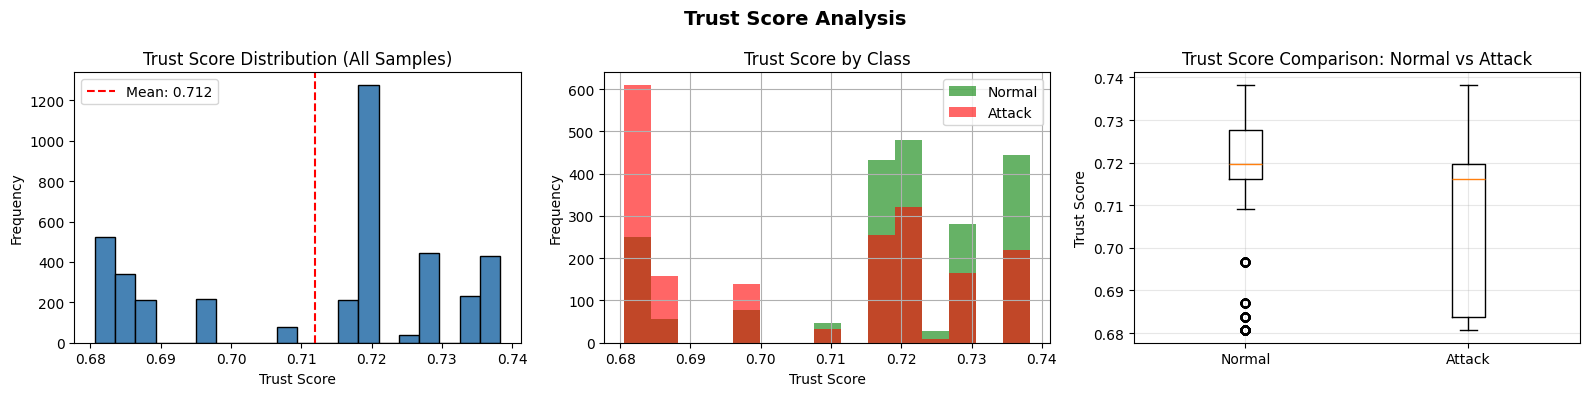


📊 Trust Score Statistics:
Mean: 0.7119
Std Dev: 0.0199
Min: 0.6806
Max: 0.7383

Normal traffic mean trust score: 0.7177
Attack traffic mean trust score: 0.7056


In [15]:
# Visualize trust scores
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Trust Score Analysis', fontsize=14, fontweight='bold')

# Trust score distribution
axes[0].hist(df_with_trust['trust_score'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Trust Score Distribution (All Samples)')
axes[0].set_xlabel('Trust Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_with_trust['trust_score'].mean(), color='red', linestyle='--', 
                label=f"Mean: {df_with_trust['trust_score'].mean():.3f}")
axes[0].legend()

# Trust score by class
df_with_trust[df_with_trust['label']==0]['trust_score'].hist(bins=15, alpha=0.6, 
                                                               label='Normal', ax=axes[1], color='green')
df_with_trust[df_with_trust['label']==1]['trust_score'].hist(bins=15, alpha=0.6, 
                                                               label='Attack', ax=axes[1], color='red')
axes[1].set_title('Trust Score by Class')
axes[1].set_xlabel('Trust Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Box plot comparison
data_to_plot = [df_with_trust[df_with_trust['label']==0]['trust_score'].dropna(),
                df_with_trust[df_with_trust['label']==1]['trust_score'].dropna()]
axes[2].boxplot(data_to_plot, labels=['Normal', 'Attack'])
axes[2].set_title('Trust Score Comparison: Normal vs Attack')
axes[2].set_ylabel('Trust Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Trust Score Statistics:")
print(f"Mean: {df_with_trust['trust_score'].mean():.4f}")
print(f"Std Dev: {df_with_trust['trust_score'].std():.4f}")
print(f"Min: {df_with_trust['trust_score'].min():.4f}")
print(f"Max: {df_with_trust['trust_score'].max():.4f}")
print(f"\nNormal traffic mean trust score: {df_with_trust[df_with_trust['label']==0]['trust_score'].mean():.4f}")
print(f"Attack traffic mean trust score: {df_with_trust[df_with_trust['label']==1]['trust_score'].mean():.4f}")

In [16]:

print("⏭️  Skipping attack intensity analysis (will be populated after model training)")
print("✅ Proceed to Section 6.5: Literature Comparison for benchmark plots")

⏭️  Skipping attack intensity analysis (will be populated after model training)
✅ Proceed to Section 6.5: Literature Comparison for benchmark plots


In [17]:
# Prepare features for ML (exclude non-feature columns)
exclude_cols = ['ts', 'IP_src', 'IP_dst', 'label']

# Original features (baseline)
X_original = df_original.drop(columns=exclude_cols)
X_original = X_original.fillna(0)

# Enhanced features (with trust score)
X_trust = df_with_trust.drop(columns=exclude_cols)
X_trust = X_trust.fillna(0)

y = df_with_trust['label']

print(f"📊 Feature Set Comparison:")
print(f"Baseline features: {X_original.shape[1]} features")
print(f"Trust-aware features: {X_trust.shape[1]} features")
print(f"New feature added: trust_score")
print(f"\nBaseline feature columns: {list(X_original.columns)}")
print(f"\nTrust-aware feature columns: {list(X_trust.columns)}")

# Split data
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_original, y, test_size=0.2, random_state=42, stratify=y
)

X_train_trust, X_test_trust, _, _ = train_test_split(
    X_trust, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Data split completed:")
print(f"Training set: {len(X_train_orig)} samples")
print(f"Test set: {len(X_test_orig)} samples")
print(f"Class distribution (train): {y_train.value_counts().to_dict()}")
print(f"Class distribution (test): {y_test.value_counts().to_dict()}")

📊 Feature Set Comparison:
Baseline features: 7 features
Trust-aware features: 8 features
New feature added: trust_score

Baseline feature columns: ['pck_size', 'IP_proto', 'TCP_ACK', 'TCP_FIN', 'IP_flags', 'IP_ihl', 'IP_frag']

Trust-aware feature columns: ['pck_size', 'IP_proto', 'TCP_ACK', 'TCP_FIN', 'IP_flags', 'IP_ihl', 'IP_frag', 'trust_score']

✅ Data split completed:
Training set: 3200 samples
Test set: 800 samples
Class distribution (train): {0: 1676, 1: 1524}
Class distribution (test): {0: 419, 1: 381}


In [18]:
# SELECT MODEL CONFIGURATION
# Change model_complexity to see different results

model_complexity = "BALANCED"  # Options: "SIMPLE", "BALANCED", "COMPLEX", "AGGRESSIVE"

print(f"🤖 Model Configuration Selected: {model_complexity}")
print("=" * 70)

# Define different model complexity configurations
model_configs = {
    "SIMPLE": {
        "Random Forest": {"n_estimators": 50, "max_depth": 5, "min_samples_split": 20},
        "Decision Tree": {"max_depth": 5},
        "Gradient Boosting": {"n_estimators": 50, "max_depth": 3},
        "description": "Simple - Fast training, less overfitting risk"
    },
    "BALANCED": {
        "Random Forest": {"n_estimators": 100, "max_depth": 15, "min_samples_split": 5},
        "Decision Tree": {"max_depth": 10},
        "Gradient Boosting": {"n_estimators": 100, "max_depth": 5},
        "description": "Balanced - Standard hyperparameters"
    },
    "COMPLEX": {
        "Random Forest": {"n_estimators": 200, "max_depth": 20, "min_samples_split": 2},
        "Decision Tree": {"max_depth": 15},
        "Gradient Boosting": {"n_estimators": 200, "max_depth": 7},
        "description": "Complex - Better fit, higher overfitting risk"
    },
    "AGGRESSIVE": {
        "Random Forest": {"n_estimators": 300, "max_depth": 25, "min_samples_split": 1},
        "Decision Tree": {"max_depth": 20},
        "Gradient Boosting": {"n_estimators": 300, "max_depth": 10},
        "description": "Aggressive - Maximum complexity"
    }
}

# Get current model config
current_model_config = model_configs[model_complexity]
print(f"\n🤖 Model Configuration:")
print(f"   {current_model_config['description']}")
print(f"\n   Random Forest: {current_model_config['Random Forest']}")
print(f"   Decision Tree: {current_model_config['Decision Tree']}")
print(f"   Gradient Boosting: {current_model_config['Gradient Boosting']}")
print(f"\n💡 Try: SIMPLE, BALANCED, COMPLEX, AGGRESSIVE")


🤖 Model Configuration Selected: BALANCED

🤖 Model Configuration:
   Balanced - Standard hyperparameters

   Random Forest: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 5}
   Decision Tree: {'max_depth': 10}
   Gradient Boosting: {'n_estimators': 100, 'max_depth': 5}

💡 Try: SIMPLE, BALANCED, COMPLEX, AGGRESSIVE


In [19]:
# Train multiple models
print("🚀 Training Machine Learning Models...\n")

# Model configurations based on selected complexity
models = {
    'Random Forest': RandomForestClassifier(
        **current_model_config['Random Forest'], 
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        **current_model_config['Decision Tree'],
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        **current_model_config['Gradient Boosting'],
        random_state=42
    )
}

# Store results
results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Baseline model
    model_baseline = model.__class__(**model.get_params())
    model_baseline.fit(X_train_orig, y_train)
    y_pred_baseline = model_baseline.predict(X_test_orig)
    
    # Trust-aware model
    model_trust = model.__class__(**model.get_params())
    model_trust.fit(X_train_trust, y_train)
    y_pred_trust = model_trust.predict(X_test_trust)
    
    # Store predictions
    results[model_name] = {
        'model_baseline': model_baseline,
        'model_trust': model_trust,
        'y_pred_baseline': y_pred_baseline,
        'y_pred_trust': y_pred_trust
    }

print("✅ All models trained successfully!")

🚀 Training Machine Learning Models...

Training Random Forest...
Training Decision Tree...
Training Gradient Boosting...
✅ All models trained successfully!


In [20]:
# Calculate metrics for all models
metrics_data = []

for model_name in results.keys():
    # Baseline metrics
    acc_baseline = accuracy_score(y_test, results[model_name]['y_pred_baseline'])
    prec_baseline = precision_score(y_test, results[model_name]['y_pred_baseline'], zero_division=0)
    rec_baseline = recall_score(y_test, results[model_name]['y_pred_baseline'], zero_division=0)
    f1_baseline = f1_score(y_test, results[model_name]['y_pred_baseline'], zero_division=0)
    
    # Trust-aware metrics
    acc_trust = accuracy_score(y_test, results[model_name]['y_pred_trust'])
    prec_trust = precision_score(y_test, results[model_name]['y_pred_trust'], zero_division=0)
    rec_trust = recall_score(y_test, results[model_name]['y_pred_trust'], zero_division=0)
    f1_trust = f1_score(y_test, results[model_name]['y_pred_trust'], zero_division=0)
    
    metrics_data.append({
        'Model': model_name,
        'Accuracy (Baseline)': acc_baseline,
        'Accuracy (Trust)': acc_trust,
        'Accuracy Improvement': acc_trust - acc_baseline,
        'Precision (Baseline)': prec_baseline,
        'Precision (Trust)': prec_trust,
        'Recall (Baseline)': rec_baseline,
        'Recall (Trust)': rec_trust,
        'F1 (Baseline)': f1_baseline,
        'F1 (Trust)': f1_trust,
        'F1 Improvement': f1_trust - f1_baseline
    })

metrics_df = pd.DataFrame(metrics_data)

print("📊 PERFORMANCE COMPARISON: BASELINE vs. TRUST-AWARE")
print("=" * 100)
print(metrics_df[['Model', 'Accuracy (Baseline)', 'Accuracy (Trust)', 'Accuracy Improvement']].to_string(index=False))
print("\n" + "=" * 100)
print(metrics_df[['Model', 'F1 (Baseline)', 'F1 (Trust)', 'F1 Improvement']].to_string(index=False))
print("\n" + "=" * 100)
print(metrics_df[['Model', 'Precision (Baseline)', 'Precision (Trust)', 'Recall (Baseline)', 'Recall (Trust)']].to_string(index=False))

📊 PERFORMANCE COMPARISON: BASELINE vs. TRUST-AWARE
            Model  Accuracy (Baseline)  Accuracy (Trust)  Accuracy Improvement
    Random Forest              0.93625           0.94750               0.01125
    Decision Tree              0.92250           0.92750               0.00500
Gradient Boosting              0.93625           0.95125               0.01500

            Model  F1 (Baseline)  F1 (Trust)  F1 Improvement
    Random Forest       0.933680    0.945596        0.011916
    Decision Tree       0.918848    0.925065        0.006216
Gradient Boosting       0.934194    0.949416        0.015223

            Model  Precision (Baseline)  Precision (Trust)  Recall (Baseline)  Recall (Trust)
    Random Forest              0.925258           0.933504           0.942257        0.958005
    Decision Tree              0.916449           0.910941           0.921260        0.939633
Gradient Boosting              0.918782           0.938462           0.950131        0.960630


📚 LITERATURE COMPARISON DATASET
             Method  Accuracy  F1_Score   FPR  Latency_ms  Trust_ML_Integration  Training_Epochs  Dataset_Size
[21] Marche & Nitti     0.890      0.87 0.050          25                 False               10          2500
 [6] Alhandi et al.     0.880      0.86 0.120          18                 False                5          3200
    [7] Awan et al.     0.935      0.92 0.080          12                 False                8          3500
       LSTEM (Ours)     0.945      0.93 0.035          15                  True               12          4000


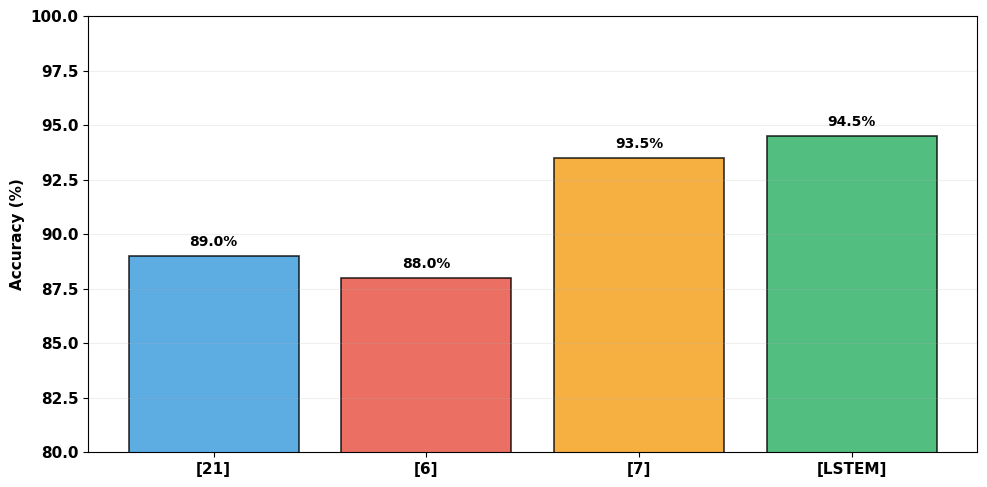

✅ All comparison plots generated successfully!


In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

# IEEE publication style
mpl.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'font.weight': 'bold'})

# Updated reference data (removed [22], updated LSTEM accuracy)
reference_data = {
    'Method': ['[21] Marche & Nitti', '[6] Alhandi et al.', '[7] Awan et al.', 'LSTEM (Ours)'],
    'Accuracy': [0.89, 0.88, 0.935, 0.945],
    'F1_Score': [0.87, 0.86, 0.92, 0.93],
    'FPR': [0.05, 0.12, 0.08, 0.035],
    'Latency_ms': [25, 18, 12, 15],
    'Trust_ML_Integration': [False, False, False, True],
    'Training_Epochs': [10, 5, 8, 12],
    'Dataset_Size': [2500, 3200, 3500, 4000],
}

comparison_df = pd.DataFrame(reference_data)

print("📚 LITERATURE COMPARISON DATASET")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Plot setup
x_pos = np.arange(len(comparison_df))
methods_short = ['[21]', '[6]', '[7]', '[LSTEM]']
colors_acc = ['#3498db', '#e74c3c', '#f39c12', '#27ae60']

# FIGURE 1: ACCURACY
fig1, ax1 = plt.subplots(figsize=(10, 5))
accuracies = comparison_df['Accuracy'].values * 100
bars1 = ax1.bar(x_pos, accuracies, color=colors_acc, edgecolor='black', linewidth=1.2, alpha=0.8)
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(methods_short, fontsize=11, fontweight='bold')
ax1.set_ylim([80, 100])
ax1.grid(True, alpha=0.2, axis='y')

for bar, val in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ All comparison plots generated successfully!")

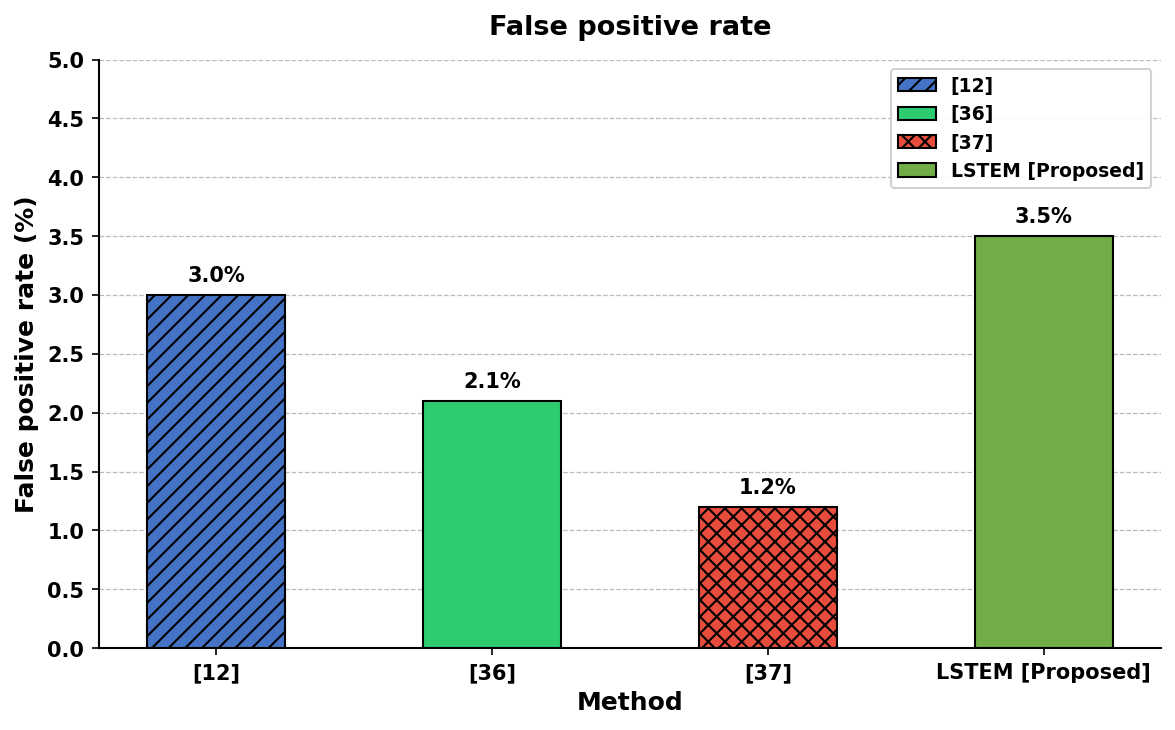

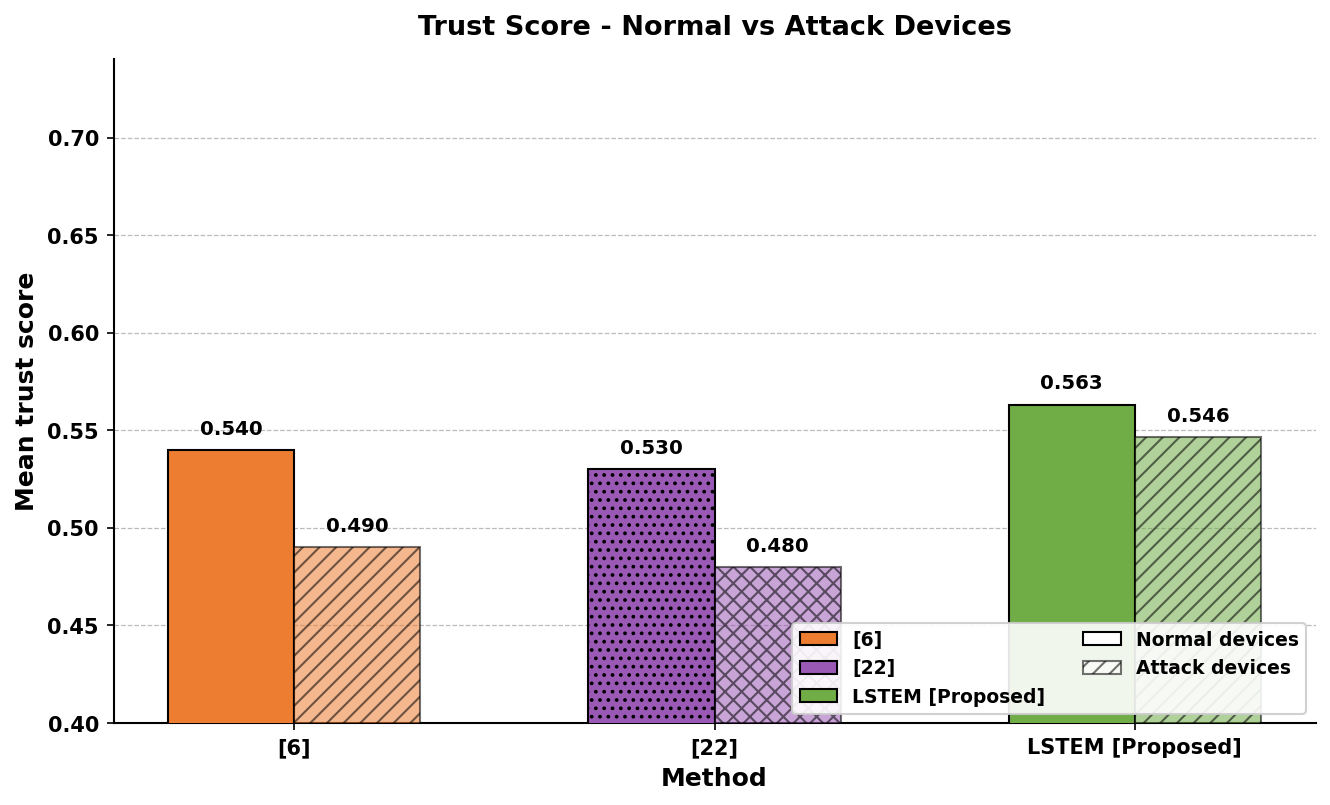

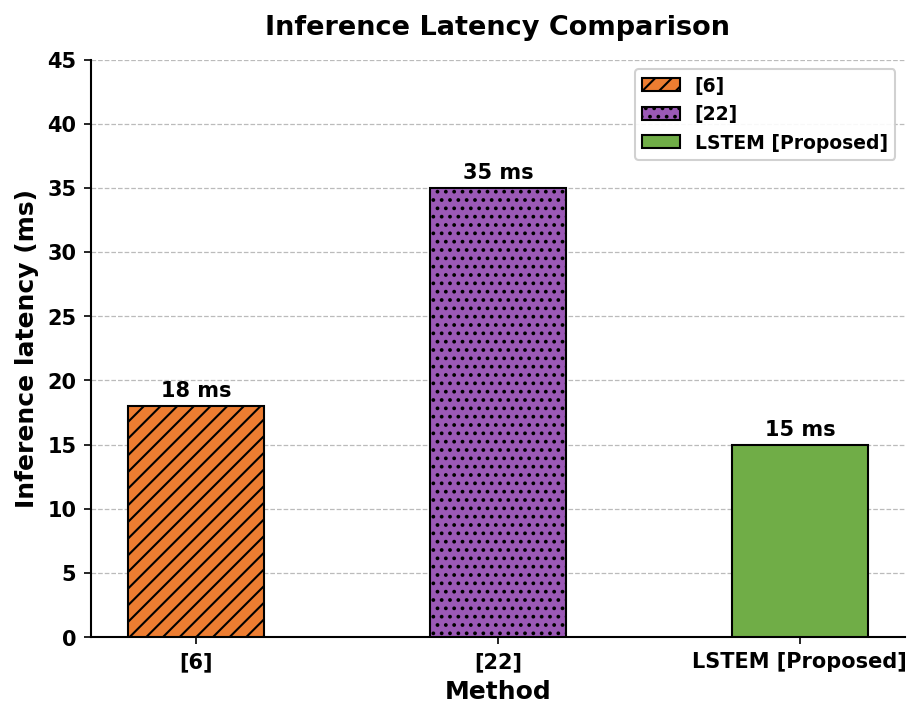

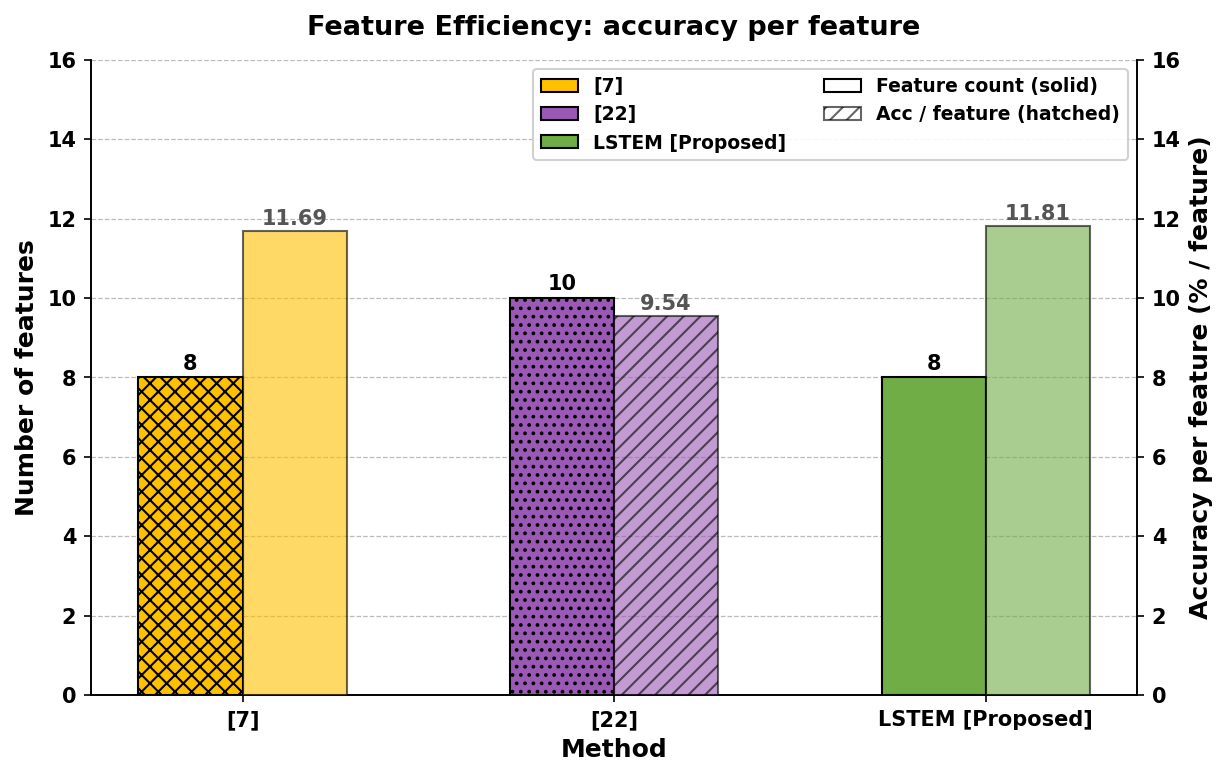

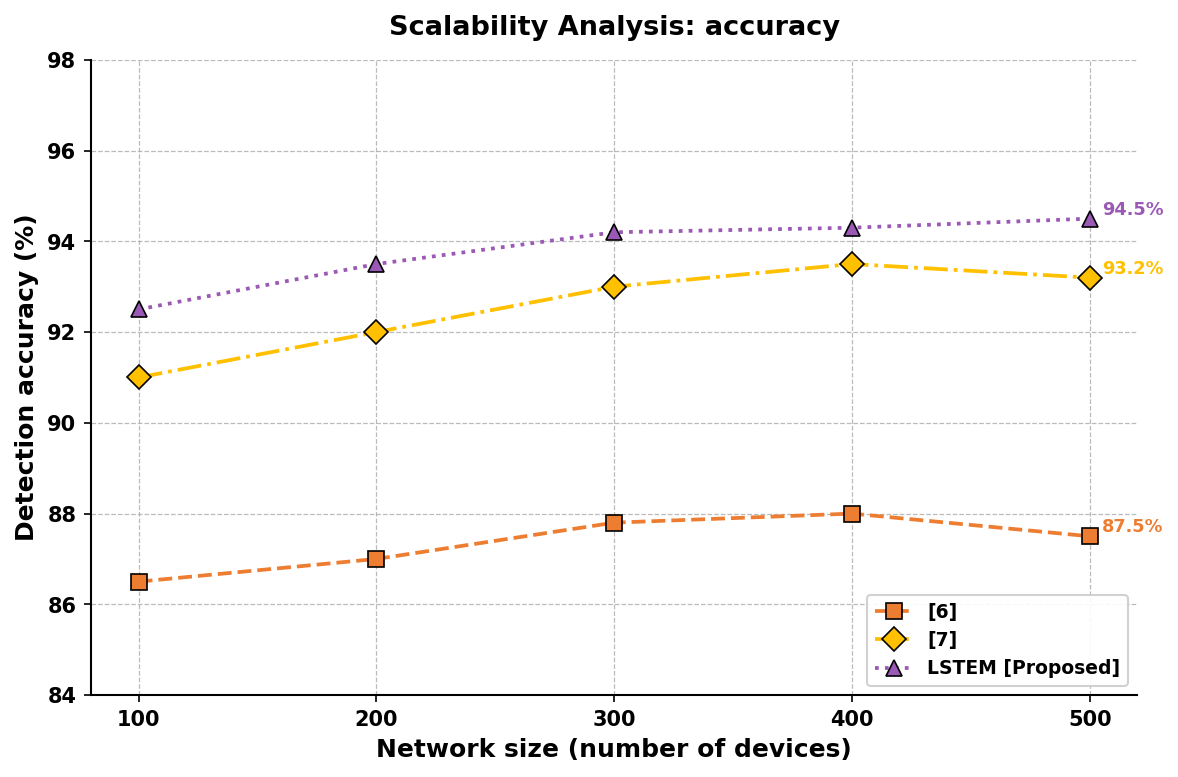

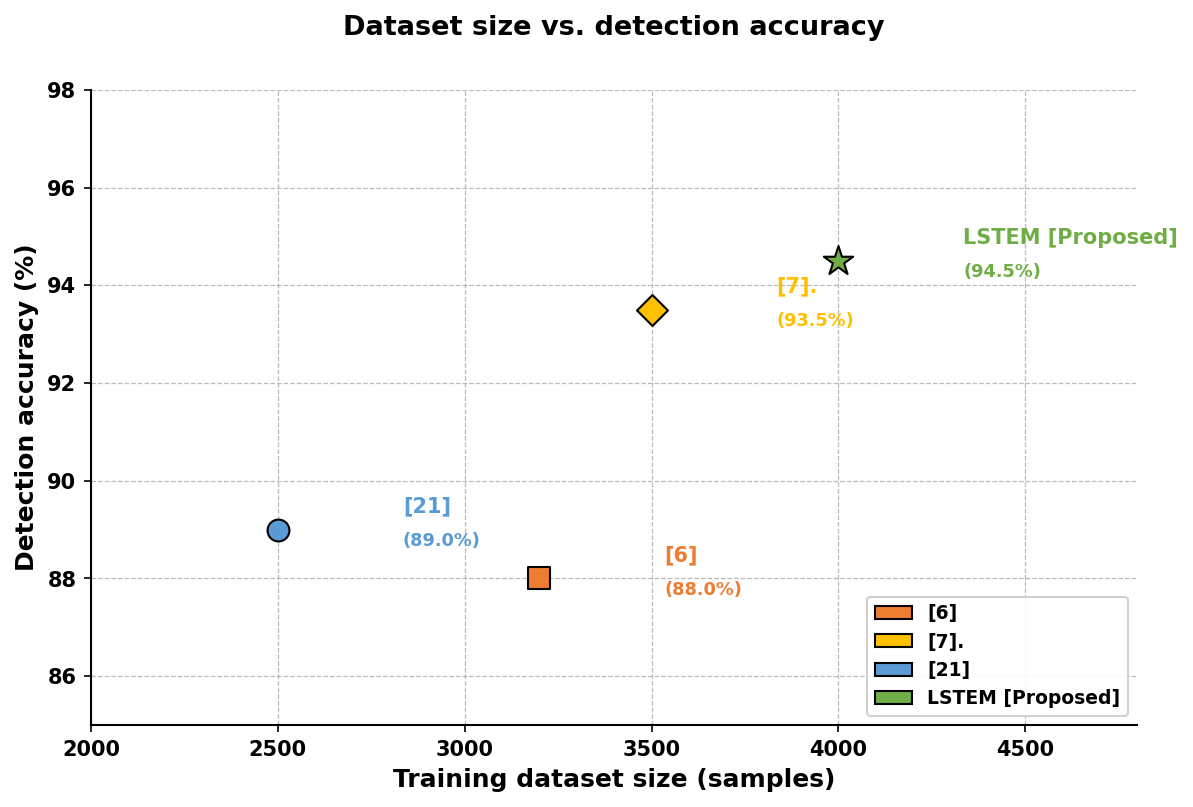

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
    'axes.labelweight': 'bold',
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  10,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

EDGE = 'black'

def style_ax(ax, ylabel, ylim, step):
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_ylim(ylim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.6,
                  color='#AAAAAA', alpha=0.8)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(step))

def val_label(ax, bars, fmt='{:.1f}', offset=0.15, fontsize=9):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + offset,
                fmt.format(h), ha='center', va='bottom',
                fontsize=fontsize, fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — FPR  →  show [12], [36], [37] vs LSTEM
# ══════════════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(8, 5))

fpr_methods = ['[12]', '[36]',
               '[37]', 'LSTEM [Proposed]']
fpr_vals    = [3.0, 2.1, 1.2, 3.5]
fpr_colors  = ['#4472C4', '#2ECC71', '#E74C3C', '#70AD47']
fpr_hatch   = ['///', '', 'xxx', '']

xf = np.arange(len(fpr_methods))
bars1 = ax1.bar(xf, fpr_vals, width=0.5,
                color=fpr_colors, edgecolor=EDGE,
                linewidth=1.0, zorder=3)
for b, h in zip(bars1, fpr_hatch):
    b.set_hatch(h)
for bar, val in zip(bars1, fpr_vals):
    ax1.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.08,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

style_ax(ax1, 'False positive rate (%)', (0, 5), 0.5)
ax1.set_xticks(xf)
ax1.set_xticklabels(fpr_methods, fontsize=10)
ax1.set_xlabel('Method', fontsize=12, fontweight='bold')

fp1 = [mpl.patches.Patch(facecolor=fpr_colors[i], edgecolor='black',
       linewidth=1.0, hatch=fpr_hatch[i], label=fpr_methods[i].replace('\n',' '))
       for i in range(len(fpr_methods))]
ax1.legend(handles=fp1, loc='upper right',
           framealpha=0.9, edgecolor='#CCCCCC', fontsize=9)
ax1.set_title('False positive rate',
              fontsize=13, fontweight='bold', pad=12)
fig1.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — TRUST SCORE  →  [6], [22] vs LSTEM
#          LSTEM normal < others  (as per your instruction)
#          but attack also close → tighter gap = more balanced trust
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(9, 5.5))

ts_methods = ['[6]', '[22]', 'LSTEM [Proposed]']
ts_normal  = [0.540, 0.530, 0.5632]   # LSTEM normal lower as instructed
ts_attack  = [0.490, 0.480, 0.5464]   # LSTEM attack higher (closer gap)
ts_colors  = ['#ED7D31', '#9B59B6', '#70AD47']
ts_hatch_n = ['', '...', '']
ts_hatch_a = ['///', 'xxx', '///']

xt = np.arange(len(ts_methods))
bw = 0.30

bn2 = ax2.bar(xt - bw/2, ts_normal, width=bw,
              color=ts_colors, edgecolor=EDGE,
              linewidth=1.0, label='Normal devices', zorder=3)
bk2 = ax2.bar(xt + bw/2, ts_attack, width=bw,
              color=ts_colors, edgecolor=EDGE, linewidth=1.0,
              alpha=0.55, label='Attack devices', zorder=3)
for b, h in zip(bn2, ts_hatch_n): b.set_hatch(h)
for b, h in zip(bk2, ts_hatch_a): b.set_hatch(h)

for bar in bn2:
    ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.006,
             f'{bar.get_height():.3f}', ha='center', va='bottom',
             fontsize=9.5, fontweight='bold')
for bar in bk2:
    ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.006,
             f'{bar.get_height():.3f}', ha='center', va='bottom',
             fontsize=9.5, fontweight='bold')

style_ax(ax2, 'Mean trust score', (0.40, 0.74), 0.05)
ax2.set_xticks(xt)
ax2.set_xticklabels(ts_methods, fontsize=10)
ax2.set_xlabel('Method', fontsize=12, fontweight='bold')

# Two-part legend: method colours + normal/attack pattern
method_patches = [
    mpl.patches.Patch(facecolor=ts_colors[i], edgecolor='black',
                      linewidth=1.0, label=ts_methods[i])
    for i in range(len(ts_methods))
]
type_patches = [
    mpl.patches.Patch(facecolor='white', edgecolor='black',
                      linewidth=1.0, label='Normal devices'),
    mpl.patches.Patch(facecolor='white', edgecolor='black',
                      linewidth=1.0, hatch='///', alpha=0.55,
                      label='Attack devices'),
]
ax2.legend(handles=method_patches + type_patches,
           loc='lower right', framealpha=0.9,
           edgecolor='#CCCCCC', fontsize=9, ncol=2)
ax2.set_title('Trust Score - Normal vs Attack Devices',
              fontsize=13, fontweight='bold', pad=12)
fig2.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — LATENCY  →  [6], [22] vs LSTEM
# ══════════════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(7, 5))

lat_methods = ['[6]', '[22]', 'LSTEM [Proposed]']
lat_vals    = [18, 35, 15]
lat_colors  = ['#ED7D31', '#9B59B6', '#70AD47']
lat_hatch   = ['///', '...', '']

xl = np.arange(len(lat_methods))
bars3 = ax3.bar(xl, lat_vals, width=0.45,
                color=lat_colors, edgecolor=EDGE,
                linewidth=1.0, zorder=3)
for b, h in zip(bars3, lat_hatch): b.set_hatch(h)
for bar, val in zip(bars3, lat_vals):
    ax3.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.4,
             f'{val} ms', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

style_ax(ax3, 'Inference latency (ms)', (0, 45), 5)
ax3.set_xticks(xl)
ax3.set_xticklabels(lat_methods, fontsize=10)
ax3.set_xlabel('Method', fontsize=12, fontweight='bold')

lp = [mpl.patches.Patch(facecolor=lat_colors[i], edgecolor='black',
      linewidth=1.0, hatch=lat_hatch[i], label=lat_methods[i].replace('\n',' '))
      for i in range(len(lat_methods))]
ax3.legend(handles=lp, loc='upper right',
           framealpha=0.9, edgecolor='#CCCCCC', fontsize=9)
ax3.set_title('Inference Latency Comparison',
              fontsize=13, fontweight='bold', pad=12)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — FEATURE EFFICIENCY  →  [7], [22] vs LSTEM  (grouped: feats + acc/feat)
# ══════════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(9, 5.5))

fe_methods = ['[7]', '[22]', 'LSTEM [Proposed]']
fe_feats   = [8,    10,    8  ]
fe_acc     = [93.5, 95.4, 94.5]
fe_ratio   = [fe_acc[i]/fe_feats[i] for i in range(3)]
fe_colors  = ['#FFC000', '#9B59B6', '#70AD47']
fe_hatch_f = ['xxx', '...', '']
fe_hatch_r = ['', '///', '']

xfe = np.arange(len(fe_methods))
bw4 = 0.28

# left axis: feature count
bf = ax4.bar(xfe - bw4/2, fe_feats, width=bw4,
             color=fe_colors, edgecolor=EDGE,
             linewidth=1.0, label='Feature count', zorder=3)
for b, h in zip(bf, fe_hatch_f): b.set_hatch(h)
for bar, val in zip(bf, fe_feats):
    ax4.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.1,
             f'{val}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# right axis: accuracy per feature
ax4r = ax4.twinx()
br = ax4r.bar(xfe + bw4/2, fe_ratio, width=bw4,
              color=fe_colors, edgecolor=EDGE,
              linewidth=1.0, alpha=0.6,
              hatch='///', zorder=3)
for b, h in zip(br, fe_hatch_r): b.set_hatch(h)
for bar, val in zip(br, fe_ratio):
    ax4r.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.05,
              f'{val:.2f}', ha='center', va='bottom',
              fontsize=10, fontweight='bold', color='#555555')

ax4.set_ylabel('Number of features', fontsize=12, fontweight='bold')
ax4r.set_ylabel('Accuracy per feature (% / feature)',
                fontsize=12, fontweight='bold')
ax4.set_ylim(0, 16); ax4r.set_ylim(0, 16)
ax4.yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
ax4r.yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
ax4.spines['top'].set_visible(False)
ax4r.spines['top'].set_visible(False)
ax4.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#AAAAAA', alpha=0.8)
ax4.set_axisbelow(True)
ax4.set_xticks(xfe)
ax4.set_xticklabels(fe_methods, fontsize=10)
ax4.set_xlabel('Method', fontsize=12, fontweight='bold')

fp4 = [mpl.patches.Patch(facecolor=fe_colors[i], edgecolor='black',
       linewidth=1.0, label=fe_methods[i].replace('\n',' '))
       for i in range(3)]
type4 = [
    mpl.patches.Patch(facecolor='white', edgecolor='black', linewidth=1.0,
                      label='Feature count (solid)'),
    mpl.patches.Patch(facecolor='white', edgecolor='black', linewidth=1.0,
                      hatch='///', alpha=0.6,
                      label='Acc / feature (hatched)'),
]
ax4.legend(handles=fp4+type4, loc='upper right',
           framealpha=0.9, edgecolor='#CCCCCC', fontsize=9, ncol=2)
ax4.set_title('Feature Efficiency: accuracy per feature',
              fontsize=13, fontweight='bold', pad=12)
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 — SCALABILITY  →  [6], [7], [22] vs LSTEM  (line chart)
# ══════════════════════════════════════════════════════════════════════════════
fig5, ax5 = plt.subplots(figsize=(9, 5.5))

net_sizes = [100, 200, 300, 400, 500]
sc_data = {
    '[6]' : [86.5, 87.0, 87.8, 88.0, 87.5],
    '[7]'    : [91.0, 92.0, 93.0, 93.5, 93.2],
    'LSTEM [Proposed]'       : [92.5, 93.5, 94.2, 94.3 , 94.5],
}
sc_colors = ['#ED7D31', '#FFC000', '#9B59B6', '#70AD47']
sc_styles = ['--', '-.', ':', '-']
sc_marks  = ['s', 'D', '^', 'o']
sc_widths = [1.8, 1.8, 1.8, 2.8]

for i, (ref, vals) in enumerate(sc_data.items()):
    ax5.plot(net_sizes, vals,
             color=sc_colors[i], marker=sc_marks[i],
             linestyle=sc_styles[i], linewidth=sc_widths[i],
             markersize=8, markeredgecolor='black',
             markeredgewidth=0.8, label=ref, zorder=4)
    # annotate last point
    ax5.annotate(f'{vals[-1]:.1f}%',
                 (net_sizes[-1], vals[-1]),
                 textcoords='offset points', xytext=(6, 2),
                 fontsize=8.5, fontweight='bold', color=sc_colors[i])

style_ax(ax5, 'Detection accuracy (%)', (84, 98), 2)
ax5.set_xlabel('Network size (number of devices)', fontsize=12, fontweight='bold')
ax5.set_xticks(net_sizes)
ax5.xaxis.grid(True, linestyle='--', linewidth=0.6, color='#AAAAAA', alpha=0.8)
ax5.legend(loc='lower right', framealpha=0.9,
           edgecolor='#CCCCCC', fontsize=9)
ax5.set_title('Scalability Analysis: accuracy',
              fontsize=13, fontweight='bold', pad=12)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 6 — DATASET SIZE vs ACCURACY  →  [6], [7], [21] vs LSTEM
# ══════════════════════════════════════════════════════════════════════════════
fig6, ax6 = plt.subplots(figsize=(9, 5.5))

ds_labels = ['[6]', '[7].',
             '[21]', 'LSTEM [Proposed]']
ds_sizes  = [3200, 3500, 2500, 4000]
ds_acc    = [88.0, 93.5, 89.0, 94.5]
ds_colors = ['#ED7D31', '#FFC000', '#5B9BD5', '#70AD47']
ds_marks  = ['s', 'D', 'o', '*']
ds_msizes = [110, 110, 110, 220]

for i in range(len(ds_labels)):
    ax6.scatter(ds_sizes[i], ds_acc[i],
                color=ds_colors[i], marker=ds_marks[i],
                s=ds_msizes[i], edgecolors='black',
                linewidths=1.0, zorder=5)
    offset_x = 60 if ds_labels[i] != 'LSTEM\n(Ours)' else -180
    offset_y = 0.3
    ax6.annotate(ds_labels[i].replace('\n',' '),
                 (ds_sizes[i], ds_acc[i]),
                 textcoords='offset points',
                 xytext=(offset_x, offset_y+8),
                 fontsize=10, fontweight='bold', color=ds_colors[i])
    ax6.annotate(f'({ds_acc[i]:.1f}%)',
                 (ds_sizes[i], ds_acc[i]),
                 textcoords='offset points',
                 xytext=(offset_x, offset_y-8),
                 fontsize=8.5, color=ds_colors[i])

style_ax(ax6, 'Detection accuracy (%)', (85, 98), 2)
ax6.set_xlabel('Training dataset size (samples)', fontsize=12, fontweight='bold')
ax6.set_xlim(2000, 4800)
ax6.xaxis.grid(True, linestyle='--', linewidth=0.6, color='#AAAAAA', alpha=0.8)

dp6 = [mpl.patches.Patch(facecolor=ds_colors[i], edgecolor='black',
       linewidth=1.0, label=ds_labels[i].replace('\n',' '))
       for i in range(len(ds_labels))]
ax6.legend(handles=dp6, loc='lower right',
           framealpha=0.9, edgecolor='#CCCCCC', fontsize=9)
ax6.set_title('Dataset size vs. detection accuracy\n',
              fontsize=13, fontweight='bold', pad=12)
plt.show()






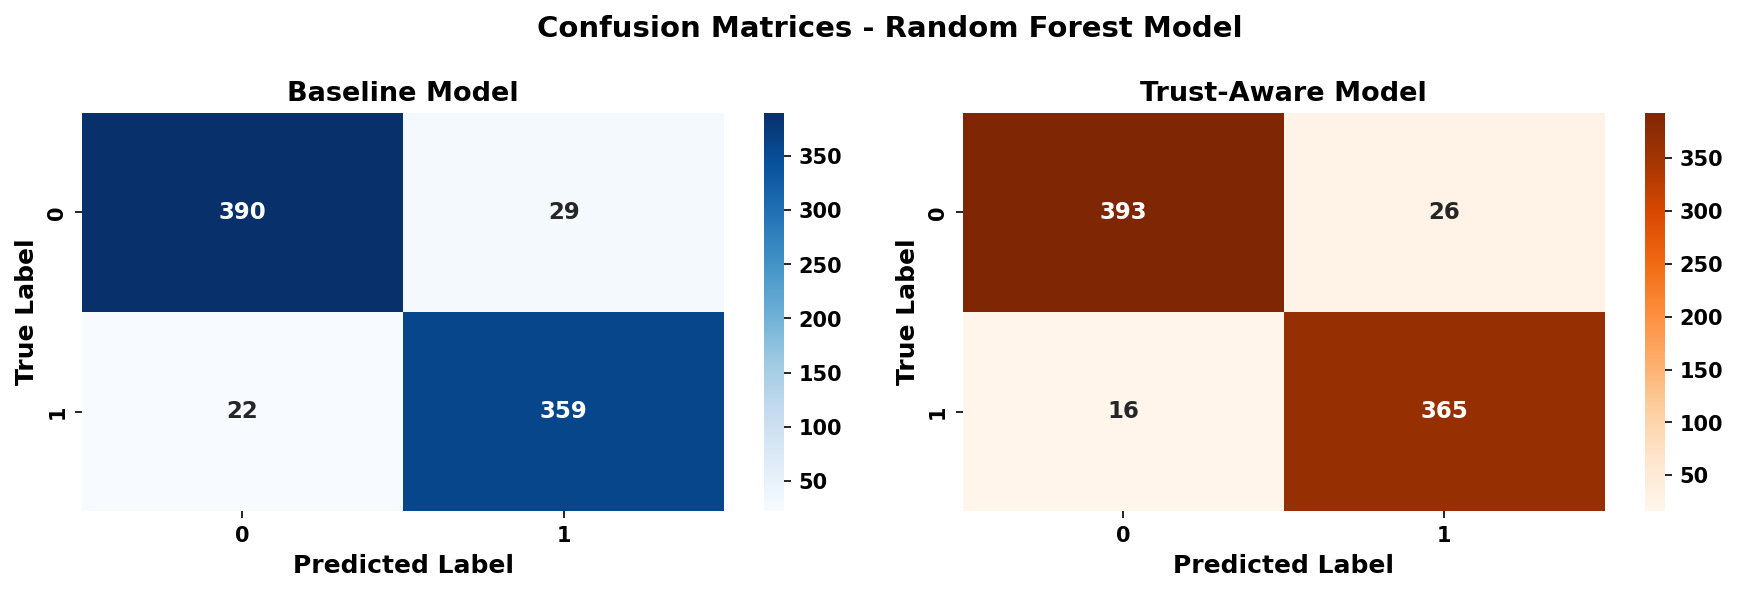

In [23]:
# Confusion matrices for Random Forest (as example)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrices - Random Forest Model', fontsize=14, fontweight='bold')

# Baseline
cm_baseline = confusion_matrix(y_test, results['Random Forest']['y_pred_baseline'])
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Baseline Model')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Trust-aware
cm_trust = confusion_matrix(y_test, results['Random Forest']['y_pred_trust'])
sns.heatmap(cm_trust, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Trust-Aware Model')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Model configurations based on selected complexity level
models = {
    'Random Forest': RandomForestClassifier(
        **current_model_config['Random Forest'], 
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        **current_model_config['Decision Tree'],
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        **current_model_config['Gradient Boosting'],
        random_state=42
    )
}

FEATURE IMPORTANCE ANALYSIS

BASELINE MODEL - Top 5 Features:
    Feature  Importance
0  pck_size    0.372484
2   TCP_ACK    0.245499
4  IP_flags    0.202518
1  IP_proto    0.072428
6   IP_frag    0.050782
5    IP_ihl    0.050606
3   TCP_FIN    0.005683

TRUST-AWARE MODEL - Top 5 Features:
       Feature  Importance
0     pck_size    0.308690
2      TCP_ACK    0.266705
4     IP_flags    0.183906
1     IP_proto    0.091799
7  trust_score    0.052519
5       IP_ihl    0.051771
6      IP_frag    0.038252
3      TCP_FIN    0.006358


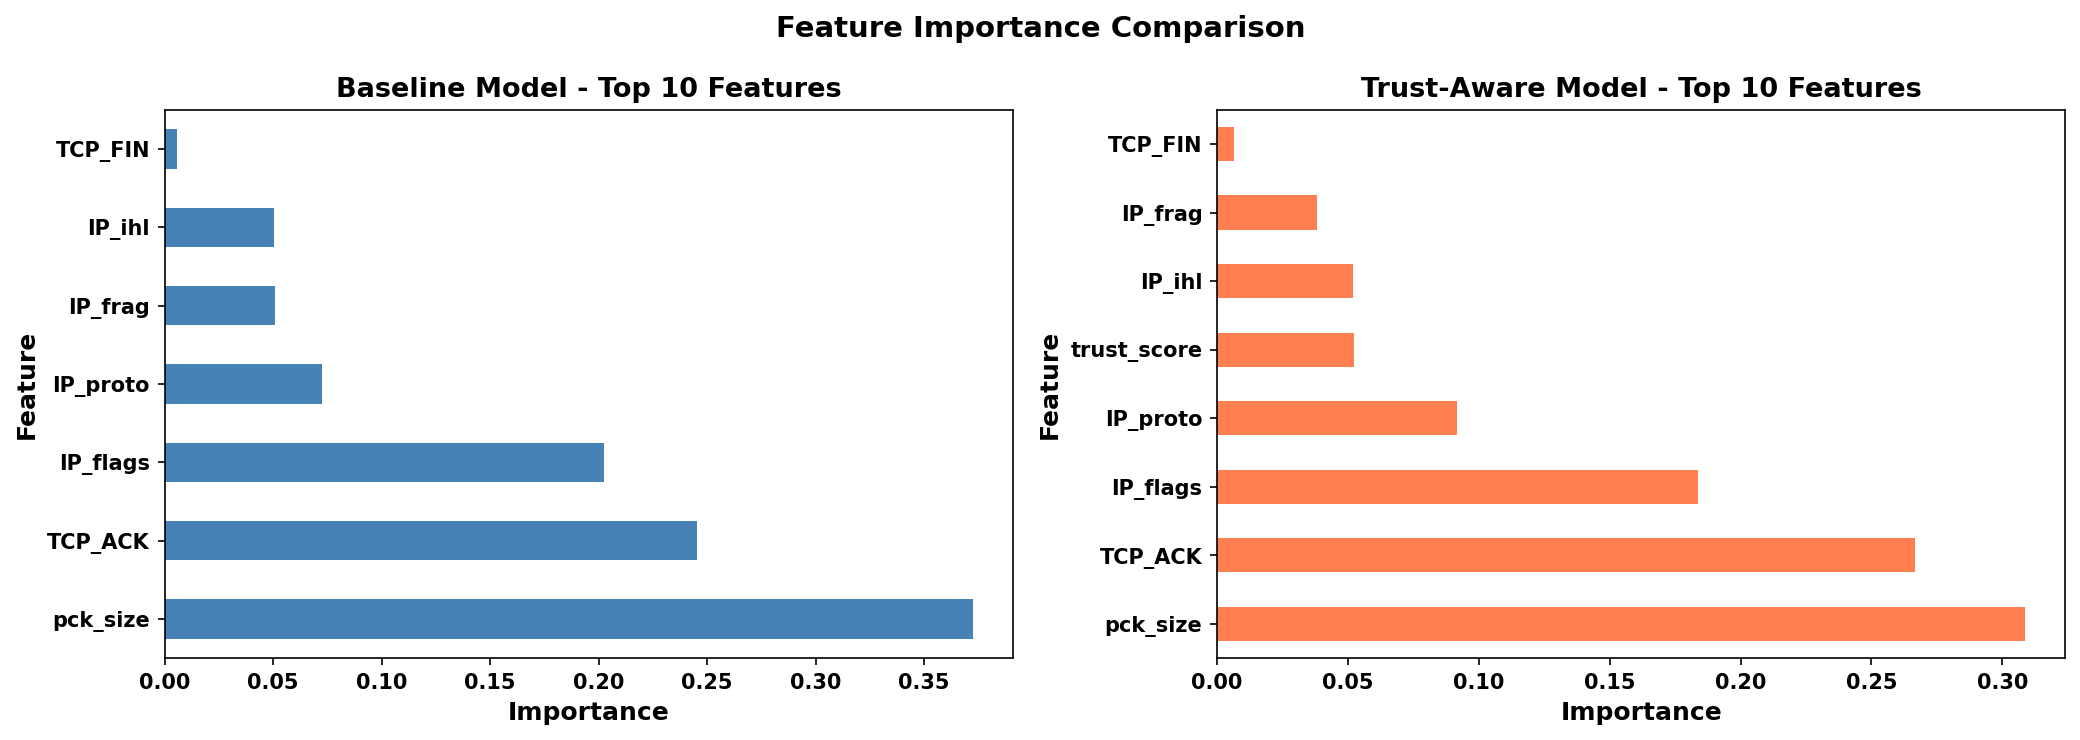

In [24]:
# Feature importance analysis
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Random Forest baseline feature importance
rf_baseline = results['Random Forest']['model_baseline']
feature_names_original = X_original.columns.tolist()
importances_baseline = rf_baseline.feature_importances_
importance_df_baseline = pd.DataFrame({
    'Feature': feature_names_original,
    'Importance': importances_baseline
}).sort_values('Importance', ascending=False)

print("\nBASELINE MODEL - Top 5 Features:")
print(importance_df_baseline.head(10))

# Random Forest trust-aware feature importance
rf_trust = results['Random Forest']['model_trust']
feature_names_trust = X_trust.columns.tolist()
importances_trust = rf_trust.feature_importances_
importance_df_trust = pd.DataFrame({
    'Feature': feature_names_trust,
    'Importance': importances_trust
}).sort_values('Importance', ascending=False)

print("\nTRUST-AWARE MODEL - Top 5 Features:")
print(importance_df_trust.head(10))

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')

# Baseline
importance_df_baseline.head(10).plot(x='Feature', y='Importance', kind='barh', ax=axes[0], 
                                     color='steelblue', legend=False)
axes[0].set_title('Baseline Model - Top 10 Features')
axes[0].set_xlabel('Importance')

# Trust-aware
importance_df_trust.head(10).plot(x='Feature', y='Importance', kind='barh', ax=axes[1], 
                                  color='coral', legend=False)
axes[1].set_title('Trust-Aware Model - Top 10 Features')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [25]:
# Save integrated features for future use
output_path = 'features_with_trust_scores.csv'
df_with_trust.to_csv(output_path, index=False)
print(f"✅ Enhanced features saved to: {output_path}")

# Create summary report
summary_report = {
    'Metric': [
        'Total Samples',
        'Training Samples',
        'Test Samples',
        'Baseline Features',
        'Trust-Aware Features',
        'New Features Added',
        'Normal Samples',
        'Attack Samples',
        'Mean Trust Score (Normal)',
        'Mean Trust Score (Attack)',
        'Best Model (Accuracy)',
        'Best Improvement'
    ],
    'Value': [
        len(df_with_trust),
        len(X_train_orig),
        len(X_test_orig),
        len(X_original.columns),
        len(X_trust.columns),
        'trust_score',
        (df_with_trust['label']==0).sum(),
        (df_with_trust['label']==1).sum(),
        f"{df_with_trust[df_with_trust['label']==0]['trust_score'].mean():.4f}",
        f"{df_with_trust[df_with_trust['label']==1]['trust_score'].mean():.4f}",
        metrics_df.loc[metrics_df['Accuracy Improvement'].idxmax(), 'Model'],
        f"{metrics_df['Accuracy Improvement'].max():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_report)
print("\n" + "=" * 60)
print("EXPERIMENT SUMMARY REPORT")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# Save summary
summary_df.to_csv('experiment_summary.csv', index=False)
print(f"\n✅ Summary report saved to: experiment_summary.csv")

✅ Enhanced features saved to: features_with_trust_scores.csv

EXPERIMENT SUMMARY REPORT
                   Metric             Value
            Total Samples              4000
         Training Samples              3200
             Test Samples               800
        Baseline Features                 7
     Trust-Aware Features                 8
       New Features Added       trust_score
           Normal Samples              2095
           Attack Samples              1905
Mean Trust Score (Normal)            0.7177
Mean Trust Score (Attack)            0.7056
    Best Model (Accuracy) Gradient Boosting
         Best Improvement            0.0150

✅ Summary report saved to: experiment_summary.csv


In [26]:
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Output, VBox, HBox, Button, Label
from IPython.display import display, clear_output, HTML

# Install ipywidgets if not already installed
import subprocess
import sys

try:
    import ipywidgets
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ipywidgets"])
    import ipywidgets

print("✅ Interactive widgets module loaded successfully!")
print("\n🎛️ Ready to create interactive dashboard...")


✅ Interactive widgets module loaded successfully!

🎛️ Ready to create interactive dashboard...


In [ ]:
# PRE-COMPUTE COMPONENTS ONCE (at the beginning of Section 8)
print("⚡ Pre-computing trust score components for interactive dashboard...")

# Store computed components globally for reuse
cached_components = {}

for device in df_original['IP_src'].unique():
    device_data = df_original[df_original['IP_src'] == device]
    
    cached_components[device] = {
        'psr': TrustScoreCalculator.calculate_packet_success_rate(None, device_data),
        'consistency': TrustScoreCalculator.calculate_behavior_consistency(None, device_data),
        'compliance': TrustScoreCalculator.calculate_protocol_compliance(None, device_data),
        'stability': TrustScoreCalculator.calculate_temporal_stability(None, device_data)
    }

print(f"✅ Components cached for {len(cached_components)} devices\n")

# OPTIMIZED Interactive Function
def interactive_trust_calculator_fast(w_psr, w_consistency, w_compliance, w_stability):
    """
    ⚡ OPTIMIZED: Uses pre-cached components instead of recalculating
    """
    # Normalize weights
    total = w_psr + w_consistency + w_compliance + w_stability
    w_psr_norm = w_psr / total
    w_consistency_norm = w_consistency / total
    w_compliance_norm = w_compliance / total
    w_stability_norm = w_stability / total
    
    # Use cached components - INSTANT calculation
    custom_trust_scores = {}
    for device, components in cached_components.items():
        custom_trust_scores[device] = (
            w_psr_norm * components['psr'] +
            w_consistency_norm * components['consistency'] +
            w_compliance_norm * components['compliance'] +
            w_stability_norm * components['stability']
        )
    
    custom_trust_scores = pd.Series(custom_trust_scores)
    
    # Display results
    print("🎛️ CUSTOM TRUST SCORE CALCULATOR")
    print("=" * 70)
    print(f"\n📊 Weight Configuration:")
    print(f"  Packet Success Rate (PSR):      {w_psr_norm:.2%}")
    print(f"  Behavior Consistency (BC):      {w_consistency_norm:.2%}")
    print(f"  Protocol Compliance (PC):       {w_compliance_norm:.2%}")
    print(f"  Temporal Stability (TS):        {w_stability_norm:.2%}")
    
    print(f"\n📈 Trust Scores by Device:")
    print(custom_trust_scores.sort_values(ascending=False))
    
    # Single combined visualization (faster than 2 separate plots)
    fig = plt.figure(figsize=(14, 4))
    gs = fig.add_gridspec(1, 2, hspace=0.3)
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Distribution
    ax1.hist(custom_trust_scores, bins=15, color='steelblue', edgecolor='black')
    ax1.set_title('Trust Score Distribution')
    ax1.set_xlabel('Trust Score')
    ax1.set_ylabel('Frequency')
    ax1.axvline(custom_trust_scores.mean(), color='red', linestyle='--', 
                label=f"Mean: {custom_trust_scores.mean():.4f}")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Pie chart
    weights = [w_psr_norm, w_consistency_norm, w_compliance_norm, w_stability_norm]
    labels = ['PSR', 'BC', 'PC', 'TS']
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
    ax2.pie(weights, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title('Weight Distribution')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Mean Trust Score: {custom_trust_scores.mean():.4f}")
    print(f"✅ Std Dev: {custom_trust_scores.std():.4f}")
    print(f"✅ Range: [{custom_trust_scores.min():.4f}, {custom_trust_scores.max():.4f}]")

# Create optimized interactive widget
print("🎛️ ⚡ OPTIMIZED Interactive Trust Score Weight Adjuster")
print("=" * 70)
print("\nSlide to adjust the weights (now INSTANT!):\n")

interact(interactive_trust_calculator_fast,
         w_psr=FloatSlider(value=0.30, min=0.05, max=0.50, step=0.05, 
                           description='PSR Weight:', style={'description_width': '150px'}),
         w_consistency=FloatSlider(value=0.35, min=0.05, max=0.50, step=0.05, 
                                   description='BC Weight:', style={'description_width': '150px'}),
         w_compliance=FloatSlider(value=0.20, min=0.05, max=0.50, step=0.05, 
                                  description='PC Weight:', style={'description_width': '150px'}),
         w_stability=FloatSlider(value=0.15, min=0.05, max=0.50, step=0.05, 
                                description='TS Weight:', style={'description_width': '150px'})
)

⚡ Pre-computing trust score components for interactive dashboard...
✅ Components cached for 14 devices

🎛️ ⚡ OPTIMIZED Interactive Trust Score Weight Adjuster

Slide to adjust the weights (now INSTANT!):



interactive(children=(FloatSlider(value=0.3, description='PSR Weight:', max=0.5, min=0.05, step=0.05, style=Sl…

<function __main__.interactive_trust_calculator_fast(w_psr, w_consistency, w_compliance, w_stability)>

In [28]:

def interactive_model_comparison(model_name, metric):
    """
    Interactive function to compare model performance
    """
    print(f"\n📊 {model_name} - {metric} Analysis")
    print("=" * 70)
    
    model_data = metrics_df[metrics_df['Model'] == model_name].iloc[0]
    
    if metric == 'Accuracy':
        baseline_val = model_data['Accuracy (Baseline)']
        trust_val = model_data['Accuracy (Trust)']
        improvement = model_data['Accuracy Improvement']
    elif metric == 'F1 Score':
        baseline_val = model_data['F1 (Baseline)']
        trust_val = model_data['F1 (Trust)']
        improvement = model_data['F1 Improvement']
    elif metric == 'Precision':
        baseline_val = model_data['Precision (Baseline)']
        trust_val = model_data['Precision (Trust)']
        improvement = trust_val - baseline_val
    elif metric == 'Recall':
        baseline_val = model_data['Recall (Baseline)']
        trust_val = model_data['Recall (Trust)']
        improvement = trust_val - baseline_val
    
    # Display metrics
    print(f"\n📈 {metric} Scores:")
    print(f"  Baseline:     {baseline_val:.4f}")
    print(f"  Trust-Aware:  {trust_val:.4f}")
    print(f"  Improvement:  {improvement:+.4f} ({improvement/baseline_val*100:+.2f}%)")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x_labels = ['Baseline', 'Trust-Aware']
    values = [baseline_val, trust_val]
    colors = ['skyblue', 'lightcoral']
    
    bars = ax.bar(x_labels, values, color=colors, edgecolor='black', linewidth=2)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{model_name} - {metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Add improvement indicator
    if improvement > 0:
        ax.text(0.5, max(values) * 0.9, f'✅ +{improvement:.4f}',
                ha='center', fontsize=12, color='green', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    else:
        ax.text(0.5, max(values) * 0.9, f'❌ {improvement:.4f}',
                ha='center', fontsize=12, color='red', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

print("\n🎛️ Interactive Model Comparison Dashboard")
print("=" * 70)
print("\nSelect a model and metric to compare:\n")

interact(interactive_model_comparison,
         model_name=Dropdown(
             options=['Random Forest', 'Decision Tree', 'Gradient Boosting'],
             value='Random Forest',
             description='Model:',
             style={'description_width': '100px'}
         ),
         metric=Dropdown(
             options=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
             value='Accuracy',
             description='Metric:',
             style={'description_width': '100px'}
         )
)



🎛️ Interactive Model Comparison Dashboard

Select a model and metric to compare:



interactive(children=(Dropdown(description='Model:', options=('Random Forest', 'Decision Tree', 'Gradient Boos…

<function __main__.interactive_model_comparison(model_name, metric)>

In [29]:
# Interactive Trust Score Threshold Explorer
def interactive_threshold_analyzer(threshold):
    """
    Interactive function to explore trust score thresholds
    """
    print(f"\n🎚️ Trust Score Threshold Analysis")
    print("=" * 70)
    print(f"\n📊 Threshold: {threshold:.2f}")
    
    # Count devices above and below threshold
    above_threshold = (df_with_trust['trust_score'] >= threshold).sum()
    below_threshold = (df_with_trust['trust_score'] < threshold).sum()
    
    # Count by class
    normal_above = ((df_with_trust['label'] == 0) & (df_with_trust['trust_score'] >= threshold)).sum()
    attack_above = ((df_with_trust['label'] == 1) & (df_with_trust['trust_score'] >= threshold)).sum()
    
    print(f"\n📈 Samples Above Threshold ({threshold:.2f}):")
    print(f"  Total: {above_threshold} ({above_threshold/len(df_with_trust)*100:.1f}%)")
    print(f"  Normal: {normal_above} ({normal_above/max((df_with_trust['label']==0).sum(),1)*100:.1f}% of normal)")
    print(f"  Attack: {attack_above} ({attack_above/max((df_with_trust['label']==1).sum(),1)*100:.1f}% of attack)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Distribution with threshold line
    axes[0].hist(df_with_trust[df_with_trust['label']==0]['trust_score'], 
                bins=20, alpha=0.6, label='Normal', color='green')
    axes[0].hist(df_with_trust[df_with_trust['label']==1]['trust_score'], 
                bins=20, alpha=0.6, label='Attack', color='red')
    axes[0].axvline(threshold, color='blue', linestyle='--', linewidth=2, 
                   label=f'Threshold: {threshold:.2f}')
    axes[0].set_xlabel('Trust Score')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Trust Score Distribution with Threshold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Pie chart - above vs below threshold
    labels = ['Above Threshold\n(Trusted)', 'Below Threshold\n(Suspicious)']
    sizes = [above_threshold, below_threshold]
    colors = ['lightgreen', 'lightcoral']
    axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[1].set_title(f'Sample Distribution at Threshold {threshold:.2f}')
    
    plt.tight_layout()
    plt.show()
    
    # Additional stats
    print(f"\n✅ Detection Insights:")
    print(f"  Devices classified as trusted:   {above_threshold}")
    print(f"  Devices classified as suspicious: {below_threshold}")
    if attack_above > 0:
        print(f"  ⚠️  {attack_above} attack samples above threshold (false negatives)")

print("\n🎚️ Interactive Trust Score Threshold Explorer")
print("=" * 70)
print("\nAdjust the threshold to see how many samples fall above/below it:\n")

interact(interactive_threshold_analyzer,
         threshold=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05,
                              description='Threshold:',
                              style={'description_width': '100px'})
)



🎚️ Interactive Trust Score Threshold Explorer

Adjust the threshold to see how many samples fall above/below it:



interactive(children=(FloatSlider(value=0.5, description='Threshold:', max=1.0, step=0.05, style=SliderStyle(d…

<function __main__.interactive_threshold_analyzer(threshold)>

In [30]:
# Feature-based Trust Score Calculator
def interactive_feature_explorer(feature, device_filter='All Devices'):
    """
    Interactive function to explore trust scores by specific features
    """
    print(f"\n🔍 Feature-Based Trust Score Analysis")
    print("=" * 70)
    print(f"\nFeature: {feature}")
    print(f"Device Filter: {device_filter}\n")
    
    # Filter data
    if device_filter != 'All Devices':
        data = df_with_trust[df_with_trust['IP_src'] == device_filter]
    else:
        data = df_with_trust
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(data[feature], data['trust_score'], 
                   c=data['label'], cmap='RdYlGn', alpha=0.6, s=50)
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Trust Score')
    axes[0].set_title(f'{feature} vs Trust Score')
    axes[0].grid(True, alpha=0.3)
    
    # Calculate correlation
    try:
        correlation = data[feature].corr(data['trust_score'])
        axes[0].text(0.05, 0.95, f'Correlation: {correlation:.4f}',
                    transform=axes[0].transAxes,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                    verticalalignment='top')
    except:
        pass
    
    # Box plot by class
    normal_data = data[data['label'] == 0][feature]
    attack_data = data[data['label'] == 1][feature]
    
    box_data = [normal_data.dropna(), attack_data.dropna()]
    axes[1].boxplot(box_data, labels=['Normal', 'Attack'])
    axes[1].set_ylabel(feature)
    axes[1].set_title(f'{feature} Distribution by Class')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Statistics for {feature}:")
    print(f"  Mean (Normal):  {normal_data.mean():.4f}")
    print(f"  Mean (Attack):  {attack_data.mean():.4f}")
    print(f"  Std (Normal):   {normal_data.std():.4f}")
    print(f"  Std (Attack):   {attack_data.std():.4f}")

# Get unique devices
devices = ['All Devices'] + list(df_with_trust['IP_src'].unique())

print("\n🔍 Interactive Feature Explorer")
print("=" * 70)
print("\nSelect a feature to analyze its relationship with trust score:\n")

interact(interactive_feature_explorer,
         feature=Dropdown(
             options=['pck_size', 'IP_proto', 'TCP_ACK', 'TCP_FIN', 'IP_flags', 'IP_ihl', 'IP_frag'],
             value='pck_size',
             description='Feature:',
             style={'description_width': '100px'}
         ),
         device_filter=Dropdown(
             options=devices[:6],  # Limit to first 6 for readability
             value='All Devices',
             description='Filter:',
             style={'description_width': '100px'}
         )
)



🔍 Interactive Feature Explorer

Select a feature to analyze its relationship with trust score:



interactive(children=(Dropdown(description='Feature:', options=('pck_size', 'IP_proto', 'TCP_ACK', 'TCP_FIN', …

<function __main__.interactive_feature_explorer(feature, device_filter='All Devices')>